# Common Libraries

In [1]:
import numpy as np
import matplotlib.pylab as plt

# Custom Libraries

In [2]:
from biomechanics_vis import plot_arm

# Functions

In [3]:
def shoulder_rotation(elv_angle, shoulder_elv, shoulder_rot):
    return rotz(elv_angle).dot(roty(-shoulder_elv)).dot(rotz(-elv_angle)).dot(rotz(shoulder_rot))

def elbow_rotation(elbow_flexion):
    return rotx(elbow_flexion)

def rotx(angle):
    angle = angle*np.pi/180
    return np.array([[1, 0, 0], [0, np.cos(angle), -np.sin(angle)], [0, np.sin(angle), np.cos(angle)]])

def roty(angle):
    angle = angle*np.pi/180
    return np.array([[np.cos(angle), 0, np.sin(angle)], [0, 1, 0], [-np.sin(angle), 0, np.cos(angle)]])

def rotz(angle):
    angle = angle*np.pi/180
    return np.array([[np.cos(angle), -np.sin(angle), 0], [np.sin(angle), np.cos(angle), 0], [0, 0, 1]])

# Params

In [4]:
L = np.array([33, 26])
upperarm_length, forearm_length = L[0], L[1]

# Setup initial pos

In [5]:
# Default: Attention posture
origin = np.array([0, 0, 0]) # Shoulder (Global origin)
elbow = np.array([0, 0, -upperarm_length]) # Elbow position relative to Shoulder
hand = np.array([0, 0, -forearm_length]) # Hand position relative to Elbow
initial_pos = np.vstack((origin, elbow, hand + elbow))

# Plot initial pos

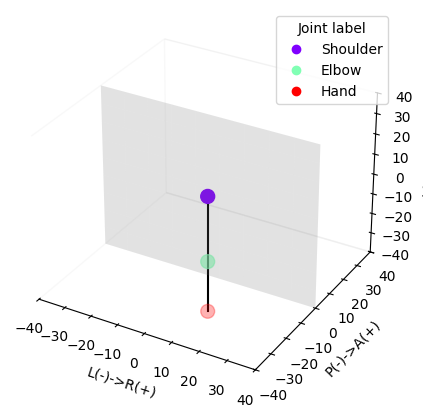

In [6]:
xmin, xmax = -40, 40
ymin, ymax = -40, 40
zmin, zmax = -40, 40

fig = plt.figure(figsize=[5, 5])
ax = fig.add_subplot(111, projection='3d')
plot_arm(ax, initial_pos[0, :], initial_pos[1, :], initial_pos[2, :])

# elevation angle plane
x_range = np.linspace(xmin, xmax, 10)
z_range = np.linspace(zmin, zmax, 10)
X, Z = np.meshgrid(x_range, z_range)
Y = np.zeros_like(X) 
ax.plot_surface(X, Y, Z, alpha=0.2, color='gray')
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_zlim(zmin, zmax)
ax.set_xlabel("L(-)->R(+)"); ax.set_ylabel("P(-)->A(+)"); ax.set_zlabel("I(-)->S(+)")
ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False
ax.grid(False)
#ax.view_init(elev=40, azim=-145)

# Interactive plot for simulating joint angles

In [7]:
from ipywidgets import interact, IntSlider

# 여러 개의 슬라이더 정의
slider1 = IntSlider(min=0, max=100, step=1, description="elv angle:", layout={'width': '400px'})
slider2 = IntSlider(min=0, max=100, step=1, description="shoulder ang:", layout={'width': '400px'})
slider3 = IntSlider(min=0, max=100, step=1, description="shoulder rot:", layout={'width': '400px'})
slider4 = IntSlider(min=0, max=100, step=1, description="elbow flex:", layout={'width': '400px'})

@interact(
    elv_angle=slider1, 
    shoulder_elv=slider2, 
    shoulder_rot=slider3, 
    elbow_flexion=slider4
)
def plot(elv_angle, shoulder_elv, shoulder_rot, elbow_flexion):
    x_range = np.linspace(xmin, xmax, 10)
    z_range = np.linspace(ymin, ymax, 10)
    X, Z = np.meshgrid(x_range, z_range)
    Y = np.zeros_like(X)
    rad = np.radians(elv_angle)
    
    X_rot = X * np.cos(rad) - Y * np.sin(rad)
    Y_rot = X * np.sin(rad) + Y * np.cos(rad)
    Z_rot = Z 

    new_elbow_loc = shoulder_rotation(elv_angle = elv_angle, 
                                      shoulder_elv = shoulder_elv, 
                                      shoulder_rot = shoulder_rot).dot(elbow)
    new_hand_loc = shoulder_rotation(elv_angle = elv_angle, 
                                     shoulder_elv = shoulder_elv, 
                                     shoulder_rot = shoulder_rot).dot(elbow_rotation(elbow_flexion = elbow_flexion).dot(hand) + elbow)
    link_pos = np.column_stack((origin, new_elbow_loc, new_hand_loc)) # shape: (#joints, xyz)

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection='3d')
    plot_arm(ax, link_pos[:, 0], link_pos[:, 1], link_pos[:, 2])
    ax.plot_surface(X_rot, Y_rot, Z_rot, alpha=0.2, color='gray')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)
    ax.set_xlabel("L(-)->R(+)"); ax.set_ylabel("P(-)->A(+)"); ax.set_zlabel("I(-)->S(+)")
    ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False
    ax.grid(False)
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='elv angle:', layout=Layout(width='400px')), IntSlider(va…